# Fenomen del món petit

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

from utils import draw_graph, draw_graphs
from netfunctions import mixing_time, cover_time

Definim les funcions per construïr les xarxes

In [3]:
# a) Anell regular
from netfunctions import anell_regular
# anell_regular(N, k)

# b) Xarxa aleatòria d'Erdős–Rényi
from netfunctions import erdos_renyi
# erdos_renyi(N, k)

# c) Xarxa de Watts–Strogatz
from netfunctions import watts_strogatz
# watts_strogatz(N, k, beta)

Funcions per $L$ i $C$

In [4]:
# L = 〈d(i,j)〉 (mitjana de les distàncies mínimes entre tots els parells de nodes)
from netfunctions import L
# L(G)

# C (proporció de triangles tancats sobre el nombre de camins de longitud 2)
from netfunctions import C
# C(G)

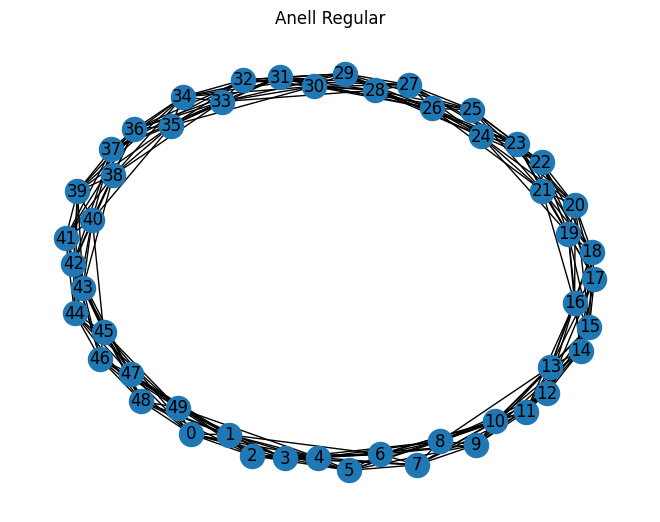

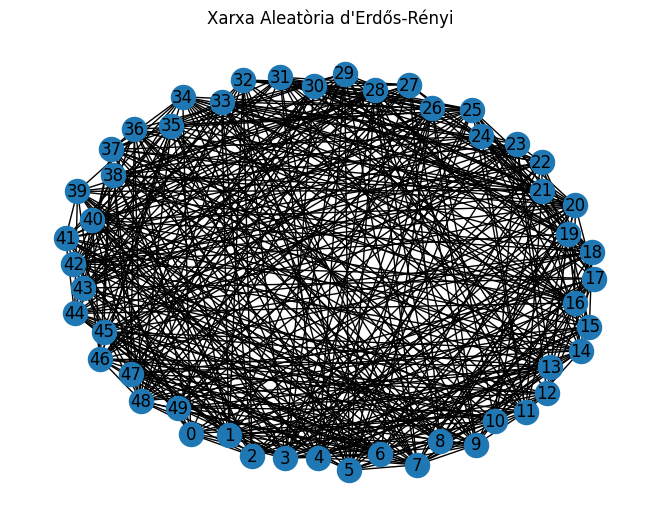

Anell Regular  : L=2.9592      ; L_norm=1.0000      ; C=0.6667      ; C_norm=1.0000      
Erdős-Rényi    : L=1.6245      ; L_norm=0.5490      ; C=0.3696      ; C_norm=0.5544      


In [5]:
# Exemples d'ús als extrems
N = 50
k = 10

G0 = anell_regular(N, k)
G1 = erdos_renyi(N,k)

# Garanteix que la posició dels nodes sigui la mateixa a cada graf
pos = nx.spring_layout(G0, seed=123)

# Calculem L0 i C0 per normalitzar
L0 = L(G0)
C0 = C(G0)

# Aquí emmagatzemem els velors de L i C (i L_norm i C_norm) per més endevant fer el gràfic
results = {} 

# draw_graphs(graphs)
draw_graph(G0, "Anell Regular", pos=pos)
draw_graph(G1, "Xarxa Aleatòria d'Erdős-Rényi", pos=pos)

results[0] = {
    "L": L(G0),
    "C": C(G0)
}
results[1] = {
    "L": L(G1),
    "C": C(G1),
}
print(f"{'Anell Regular':<15}: L={results[0]['L']:<12.4f}; L_norm={results[0]['L']/L0:<12.4f}; C={results[0]['C']:<12.4f}; C_norm={results[0]['C']/C0:<12.4f}")
print(f"{'Erdős-Rényi':<15}: L={results[1]['L']:<12.4f}; L_norm={results[1]['L']/L0:<12.4f}; C={results[1]['C']:<12.4f}; C_norm={results[1]['C']/C0:<12.4f}")

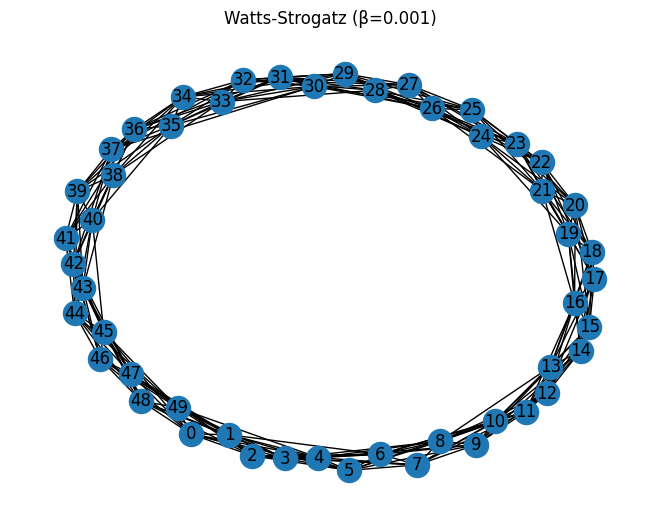

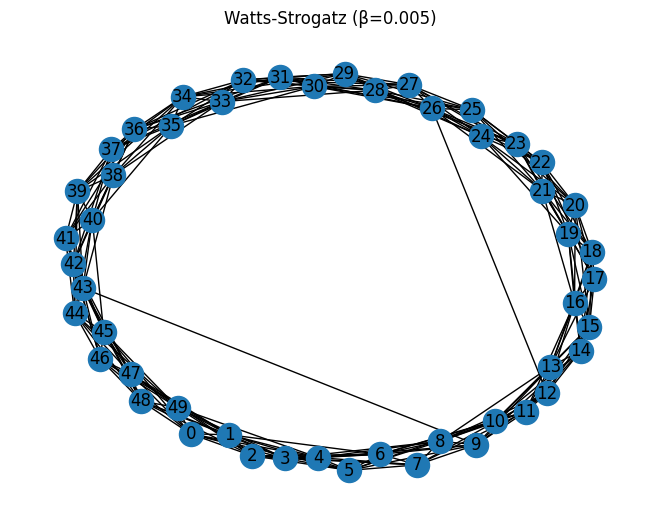

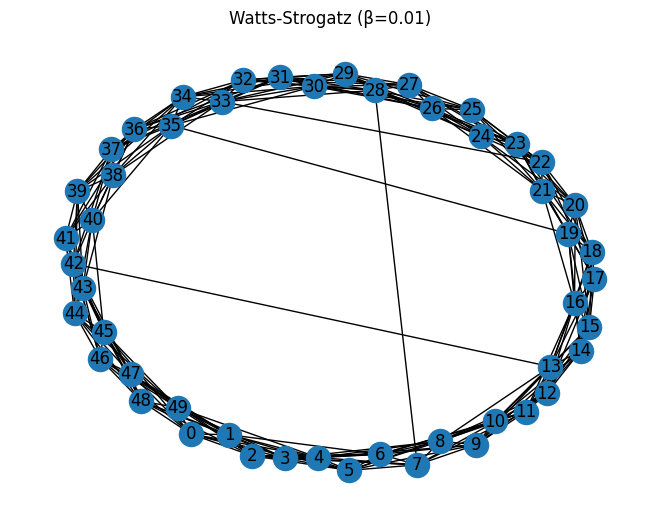

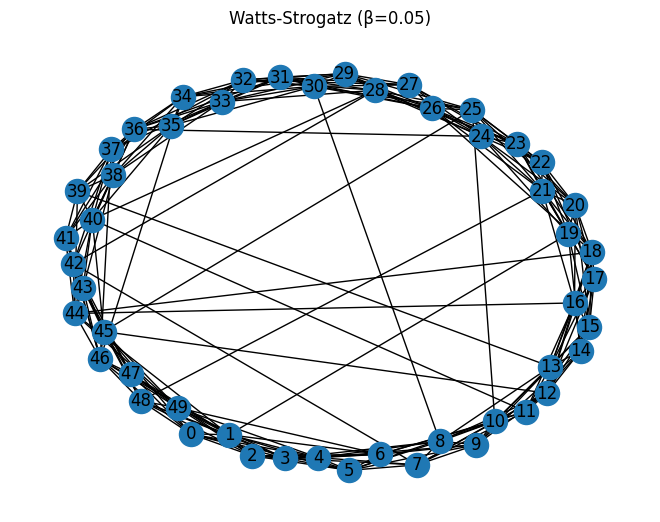

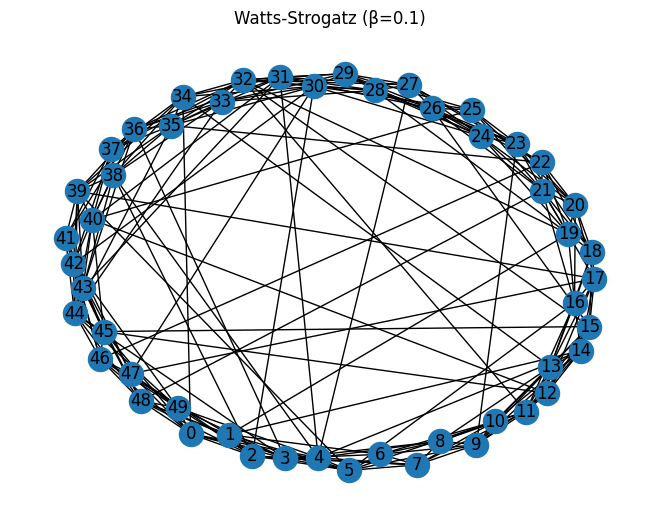

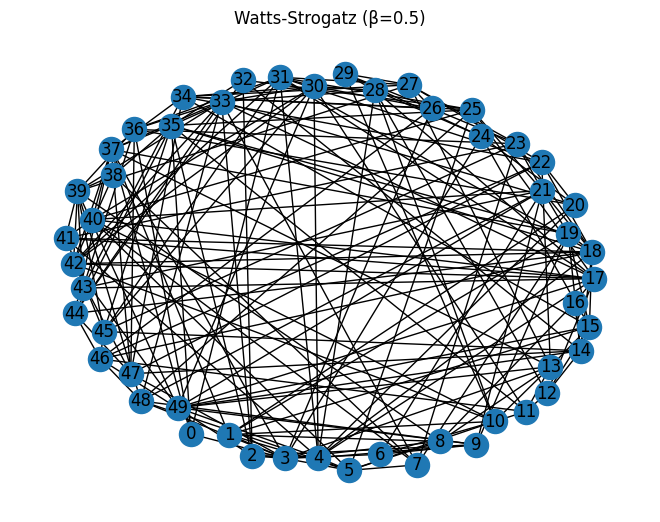

Watts-Strogatz  (β=0      ): L=2.9592      ; L_norm=1.0000      ; C=0.6667      ; C_norm=1.0000      
Watts-Strogatz  (β=0.001  ): L=2.9429      ; L_norm=0.9945      ; C=0.6599      ; C_norm=0.9898      
Watts-Strogatz  (β=0.005  ): L=2.6955      ; L_norm=0.9109      ; C=0.6493      ; C_norm=0.9739      
Watts-Strogatz  (β=0.01   ): L=2.5061      ; L_norm=0.8469      ; C=0.6410      ; C_norm=0.9615      
Watts-Strogatz  (β=0.05   ): L=2.2229      ; L_norm=0.7512      ; C=0.5138      ; C_norm=0.7707      
Watts-Strogatz  (β=0.1    ): L=2.0906      ; L_norm=0.7065      ; C=0.4271      ; C_norm=0.6407      
Watts-Strogatz  (β=0.5    ): L=2.0424      ; L_norm=0.6902      ; C=0.1784      ; C_norm=0.2677      
Watts-Strogatz  (β=1      ): L=1.6245      ; L_norm=0.5490      ; C=0.3696      ; C_norm=0.5544      


In [6]:
# Ara fem el mateix per a la xarxa de Watts–Strogatz amb les betes β ∈ {0.001, 0.005, 0.01, 0.05, 0.1, 0.5}
betes = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

for beta in betes:
    G = watts_strogatz(N, k, beta)
    draw_graph(G, f"Watts-Strogatz (β={beta})", pos=pos)
    results[beta] = {
        "L": L(G),
        "C": C(G)
    }

# Fem print ordenat per beta
sorted_results = {k: results[k] for k in sorted(results.keys())}
for beta, values in sorted_results.items():
    print(f"{'Watts-Strogatz':<15} (β={beta:<7}): L={values['L']:<12.4f}; L_norm={values['L']/L0:<12.4f}; C={values['C']:<12.4f}; C_norm={values['C']/C0:<12.4f}")

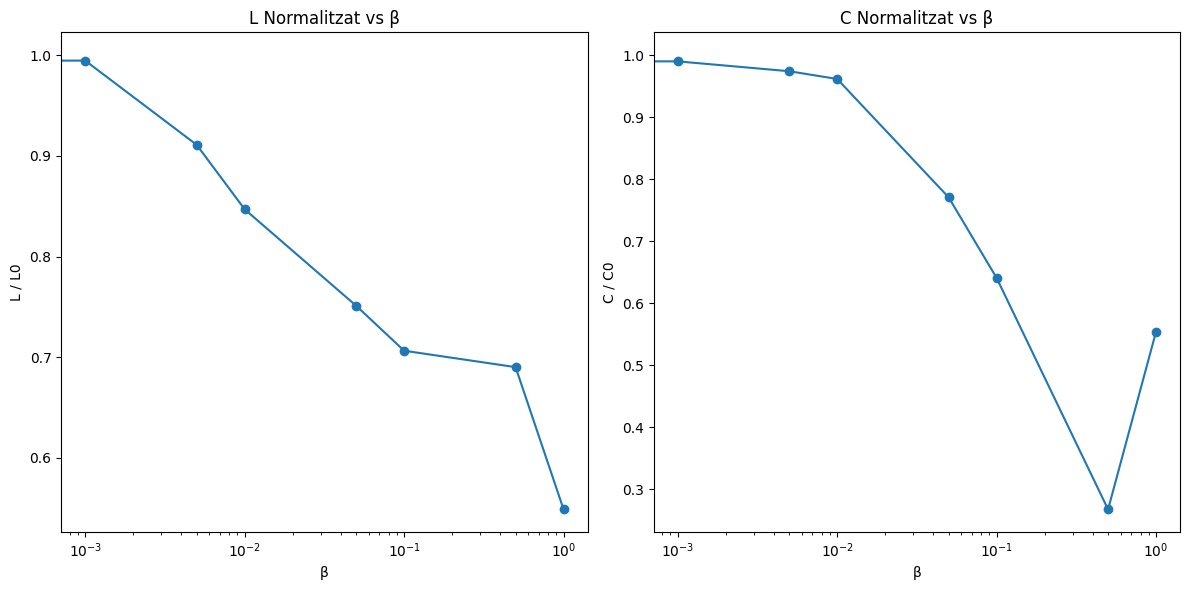

In [7]:
# Fem el gràfic de L_norm i C_norm en funció de beta
betas = list(sorted_results.keys())
L_norms = [values['L']/L0 for values in sorted_results.values()]
C_norms = [values['C']/C0 for values in sorted_results.values()]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(betas, L_norms, marker='o')
plt.xscale('log')
plt.xlabel('β')
plt.ylabel('L / L0')
plt.title('L Normalitzat vs β')
plt.subplot(1, 2, 2)
plt.plot(betas, C_norms, marker='o')
plt.xscale('log')
plt.xlabel('β')
plt.ylabel('C / C0')
plt.title('C Normalitzat vs β')
plt.tight_layout()
plt.show()

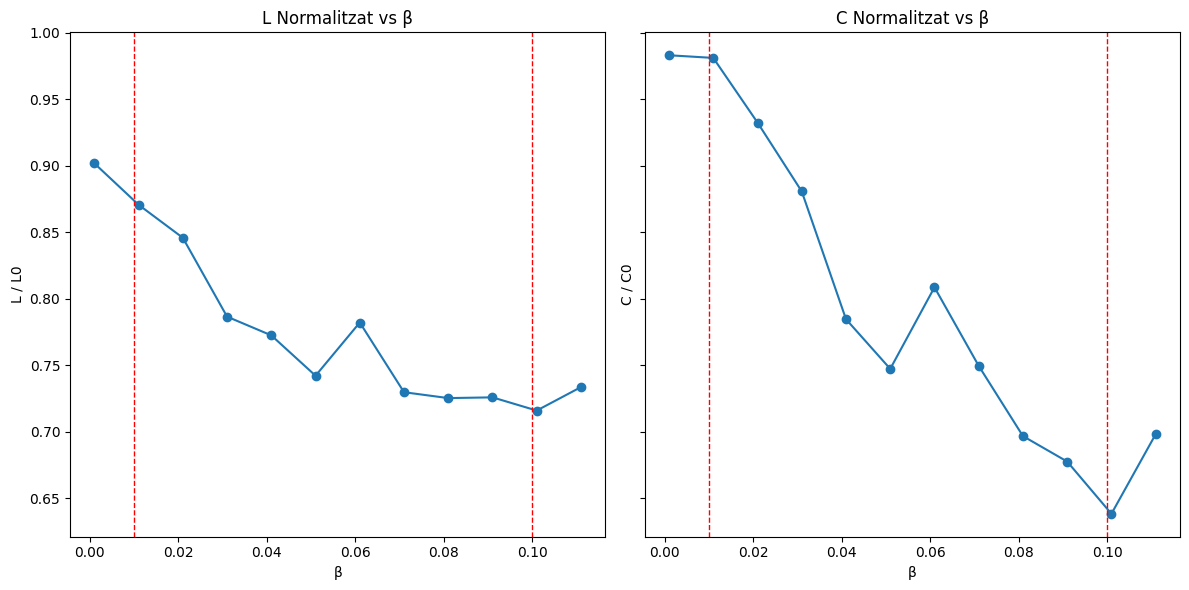

In [50]:
# Fem el mateix però amb zoom en la finestra del món petit 

results_zoom = {}

for beta in np.arange(0.001, 0.12, 0.01):
    G = watts_strogatz(N, k, beta)
    results_zoom[beta] = {
        "L": L(G),
        "C": C(G)
    }


betas = list(results_zoom.keys())
L_norms = [values['L']/L0 for values in results_zoom.values()]
C_norms = [values['C']/C0 for values in results_zoom.values()]
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes[0].plot(betas, L_norms, marker='o')
axes[0].axvline(0.01, color='red', linestyle='--', linewidth=1)
axes[0].axvline(0.1, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('β')
axes[0].set_ylabel('L / L0')
axes[0].set_title('L Normalitzat vs β')
axes[1].plot(betas, C_norms, marker='o')
axes[1].axvline(0.01, color='red', linestyle='--', linewidth=1)
axes[1].axvline(0.1, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('β')
axes[1].set_ylabel('C / C0')
axes[1].set_title('C Normalitzat vs β')
plt.tight_layout()
plt.show()

## Estudi del problema

Estudiar la proporció entre $k$ i $N$  ($k/N$). Mirar si pels valors que ens donen una proporció p tenen els mateixos resultats de $L$ i $C$.

In [ ]:
# Com que volem fer moltes simulacions i per xarxes grans, i el càclul de L és molt costós,
# comprovem que una L aproximada per 100 nodes a l'atzar és prou bona
def L_approx(G, n_samples=None):
    """
    Estima el camí mig (L) fent servir un mostreig de nodes font.
    Si n_samples és None, calcula el valor exacte (lent).
    """
    nodes = list(G.nodes())
    N = len(nodes)
    
    # Si la xarxa és petita o no especifiquem mostres, fem el càlcul exacte
    if n_samples is None or n_samples >= N:
        try:
            return nx.average_shortest_path_length(G)
        except (nx.NetworkXError, nx.NetworkXNoPath):
            return float('inf')

    # Triem n_samples nodes a l'atzar com a punts de partida
    sources = random.sample(nodes, n_samples)
    lengths = []

    for source in sources:
        # Calculem les distàncies des de 'source' a TOTS els altres nodes
        # Això és un sol BFS (molt ràpid en xarxes no pesades)
        path_lengths = nx.single_source_shortest_path_length(G, source)
        
        # Ignorem la distància al propi node (que és 0)
        distancies = [v for k, v in path_lengths.items() if k != source]
        lengths.extend(distancies)

    # Si no hem trobat camins (xarxa desconnectada), retornem inf
    if not lengths:
        return float('inf')
        
    return np.mean(lengths)

Considerem que amb `n_samples=50` obtenim una bona aproximació de L. A partir d'ara calculem L amproximant-la amb `L_aprox`.

In [ ]:
def prop_study(prop: float, beta: float):
    Ns = range(100, 1001, 20)
    ks = [N*prop for N in Ns]
    Ls = []
    Cs = []
    Ls_norm = []
    Cs_norm = []

    print(f"### Study for prop={prop}, beta={beta} ###")
    for i in range(len(Ns)):
        N = Ns[i]
        k = int(ks[i])
        G0 = anell_regular(N, k)
        L0 = L(G0)
        C0 = C(G0)
        
        if beta != 0:
            G = watts_strogatz(N, k, beta)
            if L0 != 0: # Evitem dividir per zero
                L_norm = L(G)/L0
            else:
                L_norm = float('inf')

            if C0 != 0: # Evitem dividir per zero       
                C_norm = C(G)/C0
            else:
                C_norm = float('inf')
            # print(f"N={N}, k={k}, L_norm={L_norm:.5f}, C_norm={C_norm:.5f}")
            Ls_norm.append(L_norm)
            Cs_norm.append(C_norm)
            Ls.append(L_norm*L0) 
            Cs.append(C_norm*C0)

        else: 
            Ls.append(L0)
            Cs.append(C0)
            Ls_norm.append(1) # L_norm és 1 quan beta=0
            Cs_norm.append(1) # C_norm és 1 quan beta=0
            # print(f"N={N}, k={k}, L={L0:.5f}, C={C0:.5f}")
    
    return Ls, Cs, Ls_norm, Cs_norm

In [ ]:
# Estudiem els extrems
Ls_b0, Cs_b0, Ls_norm_b0, Cs_norm_b0 = prop_study(0.1, 0)
Ls_b1, Cs_b1, Ls_norm_b1, Cs_norm_b1 = prop_study(0.1, 1)

In [ ]:
Ns = range(100, 1001, 20)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(Ns, Ls_b0, label='L (beta=0)', marker='o')
plt.xlabel('N')
plt.ylabel('L')
plt.title('L vs N (beta=0)')
plt.subplot(1, 2, 2)
plt.plot(Ns, Cs_b0, label='C (beta=0)', marker='o')
plt.xlabel('N')
plt.ylabel('C')
plt.title('C vs N (beta=0)')
plt.tight_layout()
plt.show()

$\beta=0$ és el nostre punt de referència. 

Trivialment sabem que $L_{norm} = 1$ i $C_{norm} = 1$ (com que estem normalitzant els valors dividint pel valor de la xarxa regular ($L_{norm} = \frac{L(\beta)}{L(0)}$), quan $\beta=0$ estem dividint un número per si mateix).
Això té un significat físic: La xarxa regular té la màxima clusterització (molta estructura local, molts triangles) però també la màxima distància mitjana (és molt ineficient, per creuar la xarxa has de passar node per node en un camí "llarg").

Mirant els valors no normalitzats de $L$ podem veure que si la densitat ($k/N$) es manté fixa, les propietats de la xarxa regular són independents de la seva mida ($N$) a partir d'un cert llindar.
Observem que tant $L$ com $C$ deixen de créixer bruscament i es tornen gairebé plans a partir de $N \approx 400-500$. Podem concloure que una xarxa regular de 500 nodes és "estructuralment idèntica" a una de 1000 nodes si la proporció de veïns és la mateixa. La topologia està definida per la densitat, no pel nombre absolut de nodes.

Veiem que $L$ s'estabilitza al voltant de $5.5$. Per un anell regular, la distància mitjana és aproximadament $L \approx \frac{N}{2k}$. En el nostre exemple, on la proporció és $k/N = 0.1$, $$L \approx \frac{N}{2 \cdot (0.1N)} = \frac{1}{0.2} = 5$$
El gràfic mostra que $L$ convergeix cap a un valor fix (prop de 5.5). Això demostra que, en una xarxa regular, la distància mitjana només depèn de la densitat de connexions. Si cada node coneix el 10% de la xarxa, sempre trigaràs el mateix nombre de salts per arribar a l'altre costat, independentment del nombre de nodes de la xarxa.

Respecte $C$ també podem observar coses interessants: Límit teòric de clusterització.
Veiem que al gràfic de la dreta, els punts tendeixen a un valor proper a $0.75$. No cal buscar gaire per trobar que el coeficient de clusterització teòric en un anell regular se'l pot calcular de la següent manera: $C=\frac{3(k-2)}{4(k-1)}$. Els nostres resultats ho proven. Quan $N$ creix (i per tant $k$ creix, ja que $k = p \cdot N$), el terme $\frac{k-2}{k-1}$ tendeix a $1$. Això explica per què la nostra corba s'apropa asimptòticament a 3/4 (0.75). 

In [ ]:
# Estudiem l'altre extrem, beta=1
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(Ns, Ls_norm_b1, label='L_norm (beta=1)', marker='o')
plt.xlabel('N')
plt.ylabel('L_norm')
plt.title('L_norm vs N (beta=1)')
plt.subplot(2, 2, 2)
plt.plot(Ns, Cs_norm_b1, label='C_norm (beta=1)', marker='o')
plt.xlabel('N')
plt.ylabel('C_norm')
plt.title('C_norm vs N (beta=1)')

plt.subplot(2, 2, 3)
plt.plot(Ns, Ls_b1, label='L (beta=1)', marker='o')
plt.xlabel('N')
plt.ylabel('L')
plt.title('L vs N (beta=1)')
plt.subplot(2, 2, 4)
plt.plot(Ns, Cs_b1, label='C (beta=1)', marker='o')
plt.xlabel('N')
plt.ylabel('C')
plt.title('C vs N (beta=1)')
plt.tight_layout()
plt.show()

Mentre que els gràfics de $\beta=0$ ens deien com és la "base", aquests ens diuen exactament com de millor (o pitjor) és una xarxa aleatòria respecte a la regular quan el sistema es fa gran.

$L$ i $C$ respecte la xarxa regular (normalització):
+ El gràfic de dalt a l'esquerra mostra que $L_{norm}$ baixa de $0.43$ a $0.35$ i després s'estabilitza.
    
    Això significa que a mesura que $N$ creix, la xarxa aleatòria es torna proporcionalment més eficient que la regular. Amb 100 nodes, la distància és un 43% de la original; amb 1.000 nodes, només un 35%. Això ho podriem explicar perquè en un anell regular, per anar a l'altre costat has de fer un "passeig" seqüencial. En canvi, a la xarxa aleatòria ($\beta=1$), apareixen dreceres que connecten punts oposats del cercle. A mesura que el sistema creix, l'impacte d'aquestes dreceres sobre la mitjana total és cada cop més potent fins a arribar a un límit definit per la densitat ($k/N$).

+ El gràfic de dalt a la dreta és molt interessant pel "soroll" inicial (oscil·lacions en $N < 400$).
    
    Per a valors petits de $N$, la xarxa aleatòria és molt sensible a l'atzar. Una aresta més o una menys canvia molt la proporció de triangles (hi ha una variancia alta a les mostres petites). A partir de $N=600$, la corba s'estabilitza al voltant de $0.118$. Això ens ajuda a demostrar el que sospitàvem: la ràtio de clusterització entre una xarxa aleatòria i una regular només depèn de la densitat ($k/N$). Una vegada la xarxa és prou gran, la mida ja no importa; la xarxa aleatòria sempre tindrà aproximadament un 12% de la clusterització que tindria la regular.


$L$ i $C$ d'una xarxa aleatòria:
+ El gràfic de baix a l'esquerra mostra que el camí mitjà baixa (de 2.35 a 1.9 aproximadament) a mesura que la xarxa es fa gran.

    Normalment, en fer una xarxa més gran, la distància creix. Però aquí estem mantenint la proporció $k/N$ constant. Això vol dir que, a mesura que $N$ puja, el nombre de veïns ($k$) també puja. Podríem concloure que en una xarxa aleatòria, l'augment del nombre de veïns per node té molt més impacte que l'augment del nombre total de nodes. L'atzar aprofita tan bé les noves connexions que, encara que hi hagi més nodes on anar, el caminant arriba més ràpid a tot arreu.

    Comparant-ho amb la xarxa regular on $L$ es quedava clavada en 5.5. Aquí, a $\beta=1$, la $L$ és molt més baixa (~2) i a sobre decreix. Això demostra que l'atzar és un connector **exponencialment més potent** que la proximitat física.


In [ ]:
# TODO: Ara ho estudiem per a diferents valors de beta
betas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

Fixant N i K, però variant $\beta$, per veure com afecta a L i C

In [ ]:
# Fixem una N prou gran i fem algunes simulacions per veure com varien L i L_approx
N = 2000
k = int(0.05 * N) 
betes = [10**(-k) for k in range(10, -1, -1)]

Ls = []
L_approxs = []
Cs = []

n_samples = 50


G0 = anell_regular(N, k)
L0 = L_approx(G0, n_samples=n_samples)
C0 = C(G0)

for beta in betes:
    G = watts_strogatz(N, k, beta)

    Ls.append(L(G))
    L_approxs.append(L_approx(G, n_samples=n_samples)/L0)
    Cs.append(C(G)/C0)


plt.figure(figsize=(8,5))
plt.plot(betes, L_approxs, marker='o', label='L', color='red')
plt.plot(betes, Cs, marker='o', label='C', color='blue')
plt.xscale('log')
plt.xlabel('beta')
plt.ylabel('L (vermell) i C (blau)')
plt.title(f'L i C vs beta (N={N}, k={k})')
plt.legend()
plt.tight_layout()
plt.show()

## Justificació de per què només fem servir una proporció concreta pels anàlisis

Mirar el missatge de WhatsApp de l'Albert. O preguntar-li directament

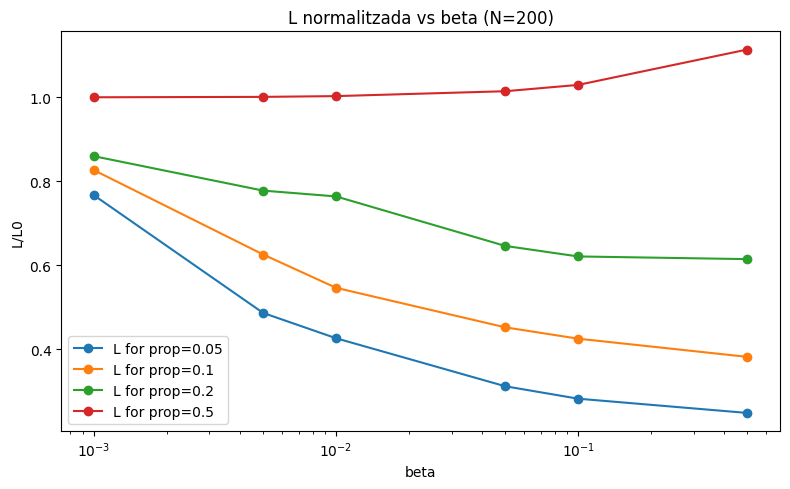

In [29]:
N = 200
props = [0.05, 0.1, 0.2, 0.5]
betas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

plt.figure(figsize=(8,5))

for prop in props:
    k = int(N * prop)
    G0 = anell_regular(N, k)
    L0 = L(G0)
    #C0 = C(G0)

    Ls_norm = []
    #Cs_norm = []

    for beta in betas:
        G = watts_strogatz(N, k, beta)
        Ls_norm.append(L(G)/L0)
        #Cs_norm.append(C(G)/C0)

    plt.plot(betas, Ls_norm, marker='o', label=f'L for prop={prop}')
    #plt.plot(betas, Cs_norm, marker='o', label='C', color='blue')
plt.xscale('log')
plt.xlabel('beta')
plt.ylabel('L/L0')
plt.title(f'L normalitzada vs beta (N={N})')
plt.legend()
plt.tight_layout()
plt.show()

## Càlcul de temps de recobriment i de mescla per a cada valor de beta

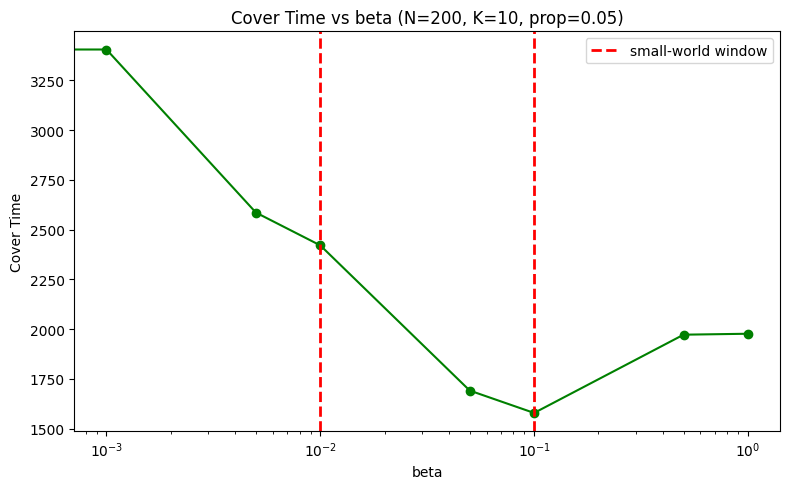

In [43]:
# Aqui comparem el temps de cobertura (cover time) pels diferents valors de beta
N = 200
prop = 0.05
K = int(prop * N)
beta_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
cover_times = []

for beta in beta_values:
    G = watts_strogatz(N, K, beta)
    cover_time_i = cover_time(G)
    cover_times.append(cover_time_i)

plt.figure(figsize=(8,5))
plt.plot(beta_values, cover_times, marker='o', color='green')
plt.xscale('log')
plt.axvline(0.01, color='red', linestyle='--', linewidth=2, label='small-world window')
plt.axvline(0.1, color='red', linestyle='--', linewidth=2)
plt.xlabel('beta')
plt.ylabel('Cover Time')
plt.title(f'Cover Time vs beta (N={N}, K={K}, prop={prop})')
plt.legend()
plt.tight_layout()
plt.show()

Com ja hem dit, emprant una proporció prou representativa, observem una relació molt clara entre el temps de recobriment i la beta. Com és evident, és a la xarxa regular (beta=0=10⁻³ aproximadament) on trobem el màxim temps necessari per transitar tots els nodes de la xarxa, mentre que a mesura que anem incrementant la probabilitat de tenir connexions aleatòries aquest temps disminueix, i ho fa de manera logarítmica (l'eix de les X es troba log-based i l'eix Y és lineal).

Observem també un fenomen curiós quan just sortim de la finestra del món petit. Sembla que el valor de beta=0.1 és el punt crític a partir del qual ja no resulta tant eficient disposar de connexions aleatòries per fer un recorregut per tota la xarxa. No ens sembla difícil de veure que efectivament, si la xarxa és completament aleatòria, arribar a tots els nodes es torna completament aleatori també, ja que ja no disposem de la clusterització que al món petit ens generava aquelles illes de nodes connectades fortuitament entre elles, sinó que en una xarxa completament aleatòria tot són illes d'un únic node. Val a dir que, així i tot, el temps necessari per recobrir tota la xarxa no és major que en la xarxa regular.

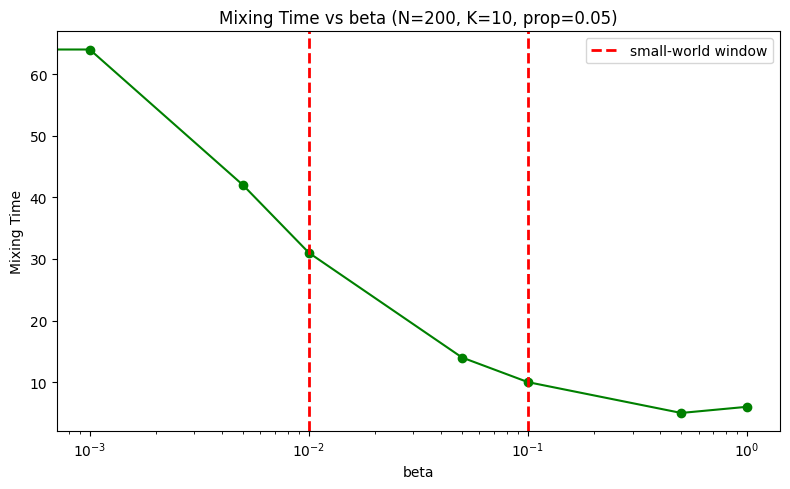

In [46]:
# Aqui comparem el temps de mescla (mixing_time) pels diferents valors de beta
N = 200
K = int(0.05 * N)
beta_values = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]
mixing_times = []

for beta in beta_values:
    G = watts_strogatz(N, K, beta)
    mixing_time_i = mixing_time(G)
    mixing_times.append(mixing_time_i)

plt.figure(figsize=(8,5))
plt.plot(beta_values, mixing_times, marker='o', color='green')
plt.xscale('log')
plt.axvline(0.01, color='red', linestyle='--', linewidth=2, label='small-world window')
plt.axvline(0.1, color='red', linestyle='--', linewidth=2)
plt.xlabel('beta')
plt.ylabel('Mixing Time')
plt.title(f'Mixing Time vs beta (N={N}, K={K}, prop={prop})')
plt.legend()
plt.tight_layout()
plt.show()

En el cas del temps de mescla, observem la mateixa tendència, però en aquest cas no es veu alterada un cop passada la finestra del món petit, ni abans d'aquesta. Es manté una relació estable al llarg de tots els valors de beta.

El temps de mescla és entés com el temps (nombre de passos) que cal deixar el passeig aleatori per tal d'arribar a la distribució estacionària que, com ja hem comentat, és la distribució uniforme en el cas de la xarxa regular, particularment, i, en general, és

$$\frac{\text{degree}(\text{node}_i)}{\sum_{j=1}^{n} \text{degree}(\text{node}_j)}$$

Això és, que un punt, comenci des d'on comenci, passat el temps de mescla, es trobarà amb més probabilitat al node que més connexions tingui (i aquest node no existirà per beta=0).

Com més aleatòria sigui la xarxa, menys passos haurem de simular, ja que cada pas equival a tornar a multiplicar per la matriu de Markov altre cop, i doncs si les connexions depenen cada cop menys de la localitat i existeixen més i més connexions aleatòries, més probable serà que aquest producte de matrius de Markov necessiti menys i menys factors per mesclar-se completament, com bé diu la paraula.

## Coses que podríem fer

+ [FET; FALTA REFLEXIÓ (Sergi?)] Calcular $L(\beta)$ i $C(\beta)$ per als valors de $\beta$ que tenim i normalitzar-los.
    + Representar-ho en un gràfic amb eix $x$ logarítmc. Ens hauria de sortir que L cau en picat mentre C es manté alt.
    + Reflexió: Per què unes poques "dreceres" tenen un impacte tan massiu en la distància mitjana però gairebé no afecten a la clusterització local?

+ [FET] Calcular `mixing_time` per a cada valor de beta.
    + Hipòtesi: En un anell regular el temps és molt alt (perquè està atrapat localment). A mida que s'augmenta $\beta$, hauria de decreixer similarment a L.
    + Comprovar si el "col·lapse" del temps de mescla coincideix amb l'aparició del fenòmen del mon petit. Això demostraria que aquest tipus de xarxes no només són curtes en distància, sinó també eficients per a processos de difusió.

+ Fixant un $\beta$ baix i variant N, comparar com creix el temps de cobertura en l'anell regular en comparació a la xarxa del mon petit.
    + Hauriem de veure que en l'anell regular el temps de cobertura creix de forma quadràtica i que en una aleatòria, molt més ràpidament $\approx N\log N$.
    + Mirar que fa la xarxa de Watts-Strogatz.

+ Visualització de la Distribució estacionària.
    + A la xarxa Erdos-renyi els graus no son iguals, fer histograma de la probabilitat estacionària de cada node.
    + Dibuixar el graf de manera que el color o mida del node depengui del seu valor a la distribució estàcionària.
    + Podem identificar els nodes centrals que actuen "com a imants" per al camí aleatori.

+ Què passa si la xarxa no és connexa?



Sembla que fer el graf dirigit complica molt les cose si hauriem de modificar moltes funcions. Si fos el cas que ho fessim, podriem mirar el següent:
+ El `cover_time` es bloquejarà fàcilment en simulació. Estudiar a mida que augmentem $\beta$ aquest bloqueig.
+ `stacionari_distribution` deixaria de funcionar, i el problema es convertiriaen l'algorisme de PageRank de Google.
+ Com calculem L? Ara el camí de A a B té longitud diferent al de B a A.